# EcoTTA Adaptation on IDRiD (VisionFM)
EcoTTA: frozen encoder + per-partition meta networks with self-distilled regularization.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/ecotta/idrid_visionfm.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Mode: every-batch (no shift detection gate)')
print('Output:', config.output_dir)

# VisionFM weights come from Google Drive; no HF token needed.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Dataset: idrid
Method: ecotta
Mode: every-batch (no shift detection gate)
Output: ./outputs/ecotta/idrid_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-08-21 10:21:58,973 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: idrid
2026-08-21 10:21:58,975 - src.models.visionfm_download - INFO - VisionFM Fundus weights found at ./cache/visionfm/VFM_Fundus_weights.pth (cached)
2026-08-21 10:22:00,170 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-21 10:22:06,114 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-21 10:22:06,115 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-21 10:22:06,190 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-21 10:22:06,233 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-21 10:22:06,234 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-21 10:22:06,652 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-0

Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

2026-08-21 10:24:35,820 - src.evaluation.runner.single - INFO -   Adapt step 0: loss=0.3413, entropy=0.8609, ent_loss=0.3187, reg=0.0451, conf_samples=1


Adapting to idrid:  14%|█▍        | 1/7 [00:03<00:23,  3.91s/it, acc=0.4375, adaptations=1]

2026-08-21 10:24:37,009 - src.evaluation.runner.single - INFO -   Adapt step 1: loss=0.3166, entropy=0.8263, ent_loss=0.2940, reg=0.0451, conf_samples=1


...

Adapting to idrid:  86%|████████▌ | 6/7 [00:10<00:01,  1.44s/it, acc=0.4375, adaptations=6]

2026-08-21 10:24:42,827 - src.evaluation.runner.single - INFO -   Adapt step 6: loss=0.7512, entropy=0.8547, ent_loss=0.7284, reg=0.0456, conf_samples=2


Adapting to idrid: 100%|██████████| 7/7 [00:10<00:00,  1.54s/it, acc=0.1429, adaptations=7]

2026-08-21 10:24:42,929 - src.evaluation.runner.single - INFO - Evaluating after adaptation on idrid


2026-08-21 10:24:51,653 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.5583
2026-08-21 10:24:51,656 - src.evaluation.runner.single - INFO - Adaptations: 7/7
2026-08-21 10:24:51,699 - src.evaluation.runner.base - INFO - Results saved to outputs/ecotta/idrid_visionfm/ctta_results.json


In [5]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

=== Results ===
Baseline QWK:        0.4957
Baseline Accuracy:   35.92%
Post-adapt QWK:      0.5583
Post-adapt Accuracy: 46.60%
Adaptations:          7/7
Adaptation rate:      100.00%
QWK change:           +0.0626
Accuracy change:      +10.68%


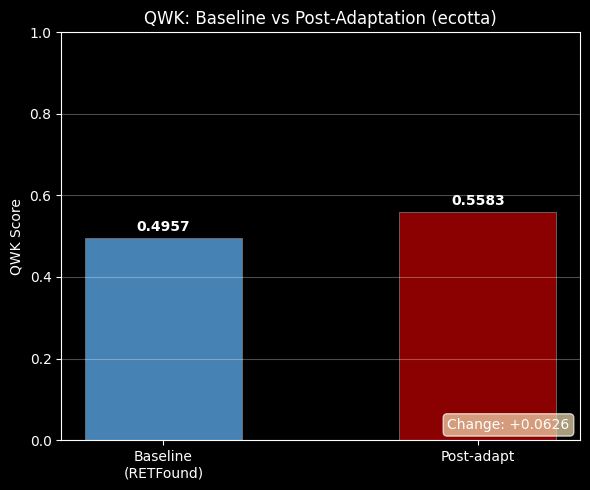

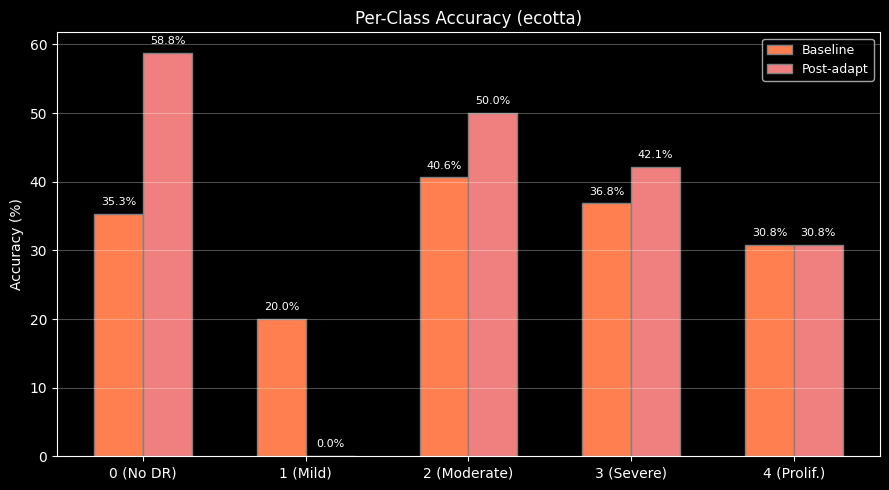

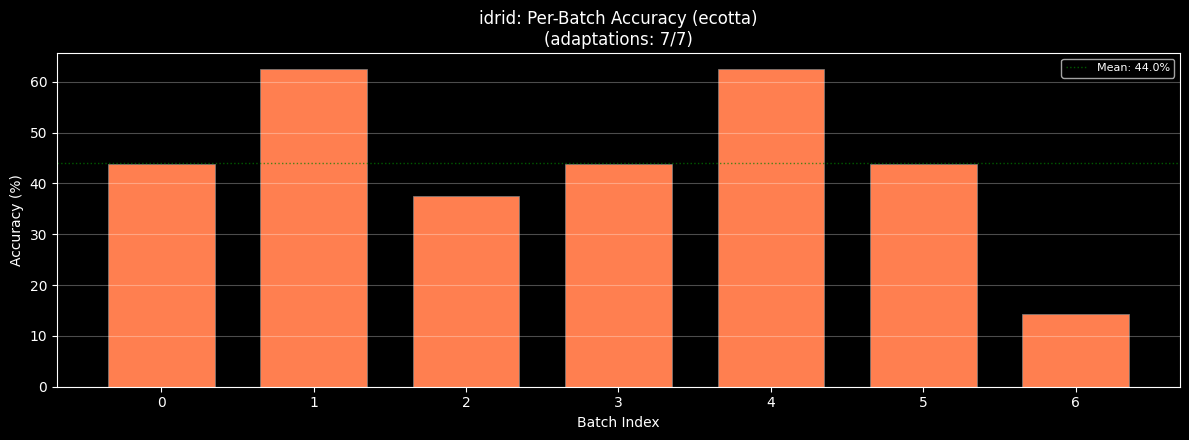

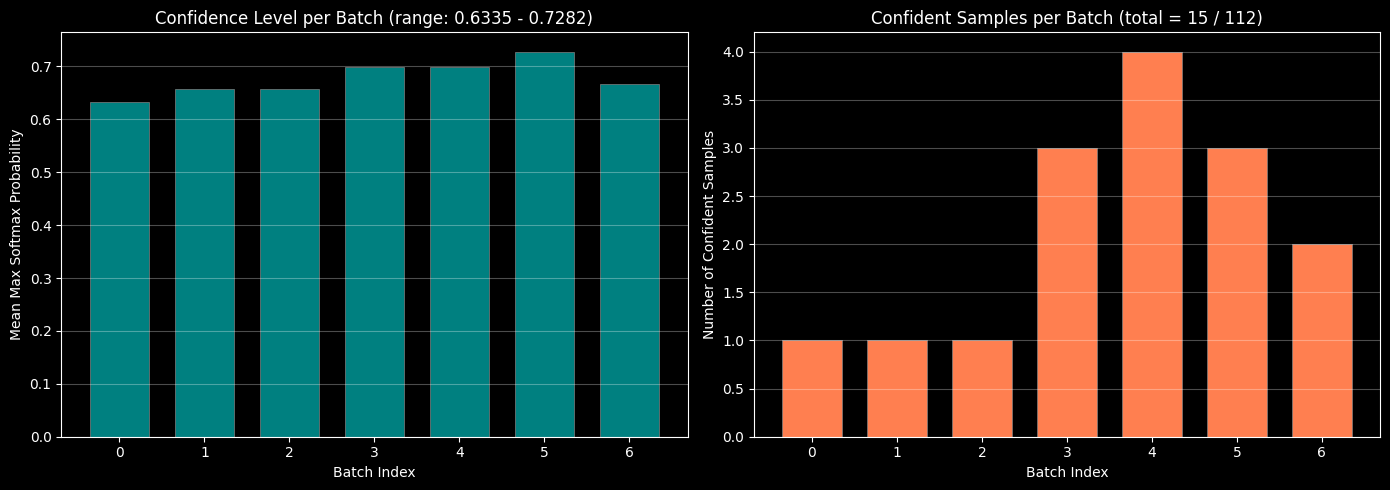

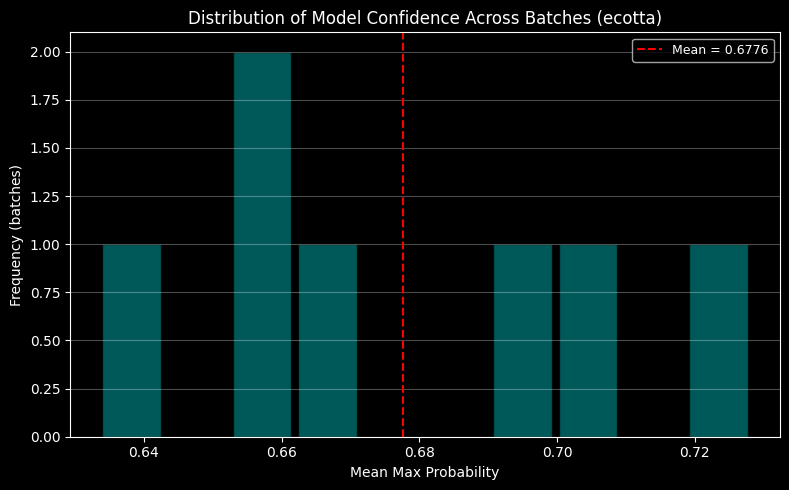

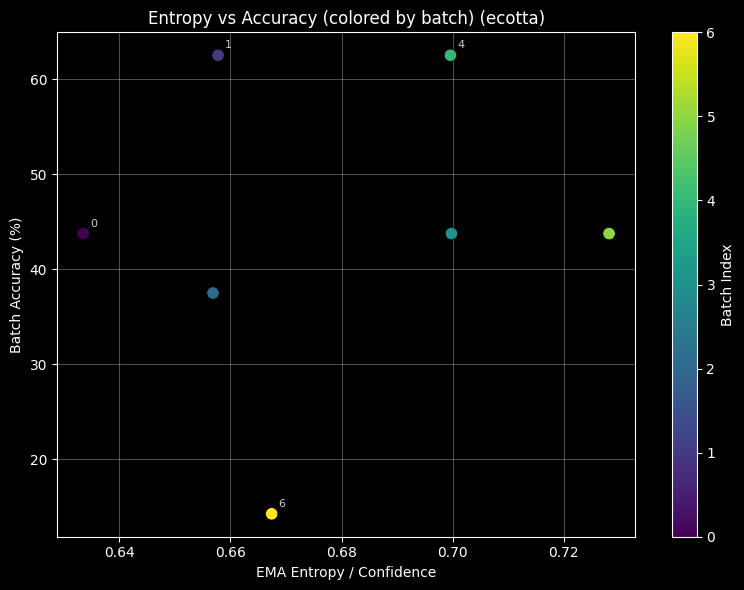

===================== CTTA Results (ecotta) =====================
Baseline QWK:       0.4957
Post-adapt QWK:     0.5583
Adaptations:        7/7
Adaptation rate:    100.00%
QWK change:         +0.0626
Mean batch acc:     44.0%


In [6]:
from src.viz import (
    get_domain_data, plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)